# Finance & Cash Flow Analysis Dashboard

A Python-based financial analysis project designed to analyse income, expenses and net cash flow.

## Project Features
- Income and expense analysis
- Expense breakdown by category
- Monthly cash flow tracking
- Financial KPI calculations
- Data visualisation
- Interactive cash flow dashboard

## Technologies
Python | Pandas | Matplotlib | ipywidgets

## Purpose
This project demonstrates the use of Python for financial data analysis, business reporting and interactive financial modelling.

## 1. Financial Data Setup

This section creates the initial financial dataset and calculates total income, total expenses and net cash flow.

In [1]:
import pandas as pd

data = {
    "Category": ["Salary", "Freelance", "Rent", "Food", "Transport", "Subscriptions"],
    "Type": ["Income", "Income", "Expense", "Expense", "Expense", "Expense"],
    "Amount": [1900, 350, 750, 280, 120, 45]
}

df = pd.DataFrame(data)

income = df[df["Type"] == "Income"]["Amount"].sum()
expenses = df[df["Type"] == "Expense"]["Amount"].sum()
cash_flow = income - expenses

print("Finance & Cash Flow Summary")
print("---------------------------")
print(f"Total income: £{income}")
print(f"Total expenses: £{expenses}")
print(f"Net cash flow: £{cash_flow}")

Finance & Cash Flow Summary
---------------------------
Total income: £2250
Total expenses: £1195
Net cash flow: £1055


## 2. Expense Analysis

This section analyses expenses by category and visualises the distribution of monthly costs.

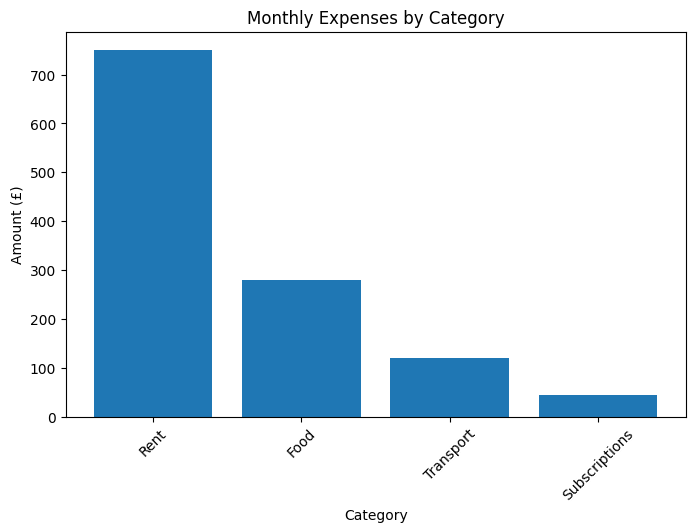

In [2]:
import matplotlib.pyplot as plt

expenses_data = df[df["Type"] == "Expense"]

plt.figure(figsize=(8, 5))
plt.bar(expenses_data["Category"], expenses_data["Amount"])

plt.title("Monthly Expenses by Category")
plt.xlabel("Category")
plt.ylabel("Amount (£)")
plt.xticks(rotation=45)

plt.show()

## 3. Monthly Cash Flow Analysis

This section tracks monthly income, expenses and net cash flow to identify financial performance trends over time.

In [4]:
monthly_data = {
    "Month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun"],
    "Income": [2100, 2250, 2200, 2400, 2350, 2500],
    "Expenses": [1350, 1195, 1280, 1420, 1310, 1380]
}

monthly_df = pd.DataFrame(monthly_data)

monthly_df["Net Cash Flow"] = monthly_df["Income"] - monthly_df["Expenses"]

monthly_df

,Month,Income,Expenses,Net Cash Flow
0,Jan,2100,1350,750
1,Feb,2250,1195,1055
2,Mar,2200,1280,920
3,Apr,2400,1420,980
4,May,2350,1310,1040
5,Jun,2500,1380,1120


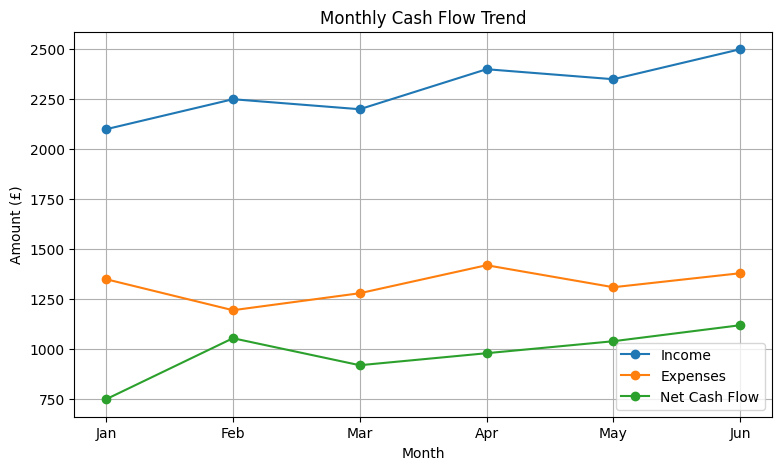

In [5]:
plt.figure(figsize=(9, 5))

plt.plot(monthly_df["Month"], monthly_df["Income"], marker="o", label="Income")
plt.plot(monthly_df["Month"], monthly_df["Expenses"], marker="o", label="Expenses")
plt.plot(monthly_df["Month"], monthly_df["Net Cash Flow"], marker="o", label="Net Cash Flow")

plt.title("Monthly Cash Flow Trend")
plt.xlabel("Month")
plt.ylabel("Amount (£)")
plt.legend()
plt.grid(True)

plt.show()

## 4. Financial KPI Summary

This section calculates key financial performance indicators, including average monthly income, average expenses, average net cash flow and the best-performing month.

In [6]:
avg_income = monthly_df["Income"].mean()
avg_expenses = monthly_df["Expenses"].mean()
avg_cash_flow = monthly_df["Net Cash Flow"].mean()

best_month = monthly_df.loc[
    monthly_df["Net Cash Flow"].idxmax(), "Month"
]

print("FINANCIAL KPI SUMMARY")
print("---------------------")
print(f"Average monthly income: £{avg_income:.2f}")
print(f"Average monthly expenses: £{avg_expenses:.2f}")
print(f"Average net cash flow: £{avg_cash_flow:.2f}")
print(f"Best cash flow month: {best_month}")

FINANCIAL KPI SUMMARY
---------------------
Average monthly income: £2300.00
Average monthly expenses: £1322.50
Average net cash flow: £977.50
Best cash flow month: Jun


## 5. Business Insights

This section translates the financial data into business insights by analysing cash flow growth, identifying the best-performing month and summarising overall financial performance.

In [7]:
# Business insights

start_cash_flow = monthly_df["Net Cash Flow"].iloc[0]
end_cash_flow = monthly_df["Net Cash Flow"].iloc[-1]

cash_flow_growth = (
    (end_cash_flow - start_cash_flow) / start_cash_flow
) * 100

best_row = monthly_df.loc[monthly_df["Net Cash Flow"].idxmax()]

print("BUSINESS INSIGHTS")
print("-----------------")
print(f"Cash flow improved by {cash_flow_growth:.1f}% between January and June.")
print(f"{best_row['Month']} generated the highest net cash flow at £{best_row['Net Cash Flow']:.2f}.")
print(f"Average monthly net cash flow was £{avg_cash_flow:.2f}.")

BUSINESS INSIGHTS
-----------------
Cash flow improved by 49.3% between January and June.
Jun generated the highest net cash flow at £1120.00.
Average monthly net cash flow was £977.50.


## 6. Interactive Cash Flow Dashboard

This section provides an interactive dashboard that allows users to enter income and expenses and calculate net cash flow dynamically.

In [8]:
import ipywidgets as widgets
from IPython.display import display, clear_output

income_input = widgets.FloatText(
    value=2300,
    description="Income £:"
)

expenses_input = widgets.FloatText(
    value=1300,
    description="Expenses £:"
)

display(income_input, expenses_input)

FloatText(value=2300.0, description='Income £:')

FloatText(value=1300.0, description='Expenses £:')

In [9]:
calculate_button = widgets.Button(
    description="Calculate Cash Flow"
)

output = widgets.Output()

def calculate_cash_flow(b):
    with output:
        clear_output()

        income = income_input.value
        expenses = expenses_input.value
        net_cash_flow = income - expenses

        print("FINANCE DASHBOARD")
        print("-----------------")
        print(f"Income: £{income:.2f}")
        print(f"Expenses: £{expenses:.2f}")
        print(f"Net Cash Flow: £{net_cash_flow:.2f}")

calculate_button.on_click(calculate_cash_flow)

display(calculate_button, output)

Button(description='Calculate Cash Flow', style=ButtonStyle())

Output()

In [12]:
def show_dashboard(b):
    with output:
        clear_output()

        income = income_input.value
        expenses = expenses_input.value
        net_cash_flow = income - expenses

        print("FINANCE DASHBOARD")
        print("-----------------")
        print(f"Income: £{income:.2f}")
        print(f"Expenses: £{expenses:.2f}")
        print(f"Net Cash Flow: £{net_cash_flow:.2f}")

        chart_data = {
            "Metric": ["Income", "Expenses", "Net Cash Flow"],
            "Amount": [income, expenses, net_cash_flow]
        }

        chart_df = pd.DataFrame(chart_data)

        plt.figure(figsize=(7, 4))
        plt.bar(chart_df["Metric"], chart_df["Amount"])
        plt.title("Financial Overview")
        plt.ylabel("Amount (£)")
        plt.show()

calculate_button.on_click(show_dashboard)

In [13]:
# Expense category inputs

rent_input = widgets.FloatText(value=750, description="Rent £:")
food_input = widgets.FloatText(value=280, description="Food £:")
transport_input = widgets.FloatText(value=120, description="Transport £:")
subscriptions_input = widgets.FloatText(value=45, description="Subscriptions £:")

display(
    rent_input,
    food_input,
    transport_input,
    subscriptions_input
)

FloatText(value=750.0, description='Rent £:')

FloatText(value=280.0, description='Food £:')

FloatText(value=120.0, description='Transport £:')

FloatText(value=45.0, description='Subscriptions £:')

In [14]:
def calculate_expenses(b):
    total_expenses = (
        rent_input.value
        + food_input.value
        + transport_input.value
        + subscriptions_input.value
    )

    expenses_input.value = total_expenses

    print(f"Total expenses: £{total_expenses:.2f}")

update_expenses_button = widgets.Button(
    description="Update Expenses"
)

update_expenses_button.on_click(calculate_expenses)

display(update_expenses_button)

Button(description='Update Expenses', style=ButtonStyle())

Total expenses: £1300.00


In [15]:
# FINAL INTERACTIVE FINANCE DASHBOARD

dashboard_button = widgets.Button(
    description="Generate Dashboard",
    button_style="success"
)

dashboard_output = widgets.Output()

def generate_dashboard(b):
    with dashboard_output:
        clear_output(wait=True)

        # Get values from input fields
        income = income_input.value

        rent = rent_input.value
        food = food_input.value
        transport = transport_input.value
        subscriptions = subscriptions_input.value

        # Calculate total expenses
        total_expenses = rent + food + transport + subscriptions

        # Calculate net cash flow
        net_cash_flow = income - total_expenses

        # Update main expenses field
        expenses_input.value = total_expenses

        # Dashboard summary
        print("FINANCE DASHBOARD")
        print("-------------------------")
        print(f"Income: £{income:.2f}")
        print(f"Total Expenses: £{total_expenses:.2f}")
        print(f"Net Cash Flow: £{net_cash_flow:.2f}")
        print()
        print("EXPENSE BREAKDOWN")
        print("-------------------------")
        print(f"Rent: £{rent:.2f}")
        print(f"Food: £{food:.2f}")
        print(f"Transport: £{transport:.2f}")
        print(f"Subscriptions: £{subscriptions:.2f}")

        # Expense chart
        categories = ["Rent", "Food", "Transport", "Subscriptions"]
        amounts = [rent, food, transport, subscriptions]

        plt.figure(figsize=(8, 5))
        plt.bar(categories, amounts)
        plt.title("Monthly Expenses by Category")
        plt.ylabel("Amount (£)")
        plt.xticks(rotation=30)
        plt.show()

dashboard_button.on_click(generate_dashboard)

display(
    income_input,
    rent_input,
    food_input,
    transport_input,
    subscriptions_input,
    dashboard_button,
    dashboard_output
)

FloatText(value=2500.0, description='Income £:')

FloatText(value=800.0, description='Rent £:')

FloatText(value=300.0, description='Food £:')

FloatText(value=150.0, description='Transport £:')

FloatText(value=50.0, description='Subscriptions £:')

Button(button_style='success', description='Generate Dashboard', style=ButtonStyle())

Output()

## 7. Conclusion

This project demonstrates how Python can be used to analyse financial data, calculate key financial metrics, visualise trends and build an interactive cash flow dashboard.

The project combines data analysis, business insights and interactive user inputs to create a practical finance-focused analytical tool.